In [38]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import i24_motion_macro
import i24_motion_data
import optuna

In [39]:
@dataclass
class TriangularFD:
    """
    Triangular fundamental diagram (per lane):
      - free-flow branch: q = v_f * rho
      - congested branch: q = w * (rho_j - rho)
    Units (SI recommended):
      rho: veh/m
      q:   veh/s
      v_f: m/s
      w:   m/s  (positive magnitude of backward wave speed)
      rho_j: veh/m
    """
    v_f: float    # free-flow speed (m/s)
    w: float      # congestion wave speed magnitude (m/s), positive
    rho_j: float  # jam density (veh/m)

    """
    @property
    def rho_c(self) -> float:
        # critical density where v_f * rho = w * (rho_j - rho)
        return (self.w / (self.v_f + self.w)) * self.rho_j
    """

    @staticmethod
    def flow(rho, v_f, w, rho_j):
        return v_f*rho*(1.0 - (rho/rho_j))

    @property
    def rho_c(self) -> float:
        return self.rho_j / 2.0

    @property
    def q_max(self) -> float:
        return self.flow(self.rho_c, self.v_f, self.w, self.rho_j)
    
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        #print("Demand: ")
        #print(rho)
        rho_old = rho
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.minimum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        #print("Supply: ")
        #print(rho)
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.maximum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    """
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.v_f * rho, self.q_max)


    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.w * (self.rho_j - rho), self.q_max)
    """


@dataclass
class CTMConfig:
    dx: float  # cell length (m)
    dt: float  # time step (s)
    lanes: int
    lambda_lc: float = 0.0


    def check_cfl(self, fd: TriangularFD) -> None:
        # CTM/Godunov stability: dt <= dx / max(v_f, w)
        vmax = max(fd.v_f, fd.w)
        if self.dt > self.dx / vmax + 1e-12:
            raise ValueError(
                f"CFL violated: dt={self.dt} > dx/max(v_f,w)={self.dx/vmax:.6f}"
            )


class CTMSolver:
    """
    Multi-lane CTM solver (lanes are independent here).
    rho shape: (lanes, n_cells)

    Coupling:
      - You can specify measured boundary flows (veh/s per lane):
          q_left[l]  : flow entering cell 0 from left boundary
          q_right[l] : flow leaving last cell to right boundary
        If not provided, solver uses "open boundary" by default:
          q_left  = demand(virtual upstream density) limited by supply(cell0)
          q_right = demand(lastcell) limited by supply(virtual downstream density)
        But for micro–macro coupling, you typically provide q_left/q_right
        from spawn/despawn counters (or metering gate logic).
    """
    def __init__(self, rho_init: np.ndarray, fd: TriangularFD, cfg: CTMConfig):
        if rho_init.ndim != 2:
            raise ValueError("rho_init must be 2D: (lanes, n_cells)")
        if rho_init.shape[0] != cfg.lanes:
            raise ValueError("rho_init lanes mismatch")
        self.rho = rho_init.astype(np.float64, copy=True)
        self.fd = fd
        self.cfg = cfg
        self.cfg.check_cfl(fd)

    @property
    def lanes(self) -> int:
        return self.cfg.lanes

    @property
    def n_cells(self) -> int:
        return self.rho.shape[1]

    def step(
        self,
        q_left: Optional[np.ndarray] = None,
        q_right: Optional[np.ndarray] = None,
        rho_upstream: Optional[np.ndarray] = None,
        rho_downstream: Optional[np.ndarray] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Advance one CTM step.

        Inputs:
          q_left:  shape (lanes,) measured inflow into cell 0 (veh/s)
          q_right: shape (lanes,) measured outflow from last cell (veh/s)

          If q_left is None, you can provide rho_upstream (lanes,) as a "ghost density"
          to compute a Godunov boundary flux. Same for q_right with rho_downstream.

        Returns:
          (F, rho_new)
          F: interface fluxes shape (lanes, n_cells+1) where:
             F[:,0]       = left boundary inflow into cell 0
             F[:,i+1]     = flux from cell i -> i+1 (for i=0..n_cells-2)
             F[:,-1]      = right boundary outflow from last cell
        """
        L, N = self.rho.shape
        dx, dt = self.cfg.dx, self.cfg.dt

        #rho = np.clip(self.rho, 0.0, self.fd.rho_j)
        rho = self.rho

        # Compute interior demands/supplies
        D = self.fd.demand(rho)   # (L,N)
        S = self.fd.supply(rho)   # (L,N)

        # Flux array: interfaces 0..N (N+1 interfaces)
        F = np.zeros((L, N + 1), dtype=np.float64)

        # --- Left boundary flux F[:,0] ---
        if q_left is not None:
            q_left = np.asarray(q_left, dtype=np.float64)
            if q_left.shape != (L,):
                raise ValueError("q_left must have shape (lanes,)")
            # Can't exceed receiving capacity of cell 0
            F[:, 0] = np.clip(q_left, 0.0, S[:, 0])
        else:
            # Godunov/open boundary using upstream ghost density
            if rho_upstream is None:
                # default: "infinite demand" upstream (i.e., inject up to supply)
                D_up = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_upstream = np.asarray(rho_upstream, dtype=np.float64)
                rho_upstream = np.clip(rho_upstream, 0.0, self.fd.rho_j)
                if rho_upstream.shape != (L,):
                    raise ValueError("rho_upstream must have shape (lanes,)")
                D_up = self.fd.demand(rho_upstream)
            F[:, 0] = np.minimum(D_up, S[:, 0])

        # --- Interior fluxes F[:,1..N-1] (cell i -> i+1) ---
        for i in range(N - 1):
            F[:, i + 1] = np.minimum(D[:, i], S[:, i + 1])

        # --- Right boundary flux F[:,-1] ---
        if q_right is not None:
            q_right = np.asarray(q_right, dtype=np.float64)
            if q_right.shape != (L,):
                raise ValueError("q_right must have shape (lanes,)")
            # Can't exceed sending capacity of last cell
            F[:, -1] = np.clip(q_right, 0.0, D[:, -1])
        else:
            # Godunov/open boundary using downstream ghost density
            if rho_downstream is None:
                # default: "infinite supply" downstream (i.e., accept up to demand)
                S_dn = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_downstream = np.asarray(rho_downstream, dtype=np.float64)
                rho_downstream = np.clip(rho_downstream, 0.0, self.fd.rho_j)
                if rho_downstream.shape != (L,):
                    raise ValueError("rho_downstream must have shape (lanes,)")
                S_dn = self.fd.supply(rho_downstream)
            F[:, -1] = np.minimum(D[:, -1], S_dn)

        # --- Update densities by conservation ---
        # rho_i^{n+1} = rho_i^n - (dt/dx)(F_{i+1/2} - F_{i-1/2})            
        rho_new = rho - (dt / dx) * (F[:, 1:] - F[:, :-1])
        # --- Lane coupling: speed-difference incentive + gap acceptance ---
        if self.cfg.lambda_lc > 0.0 and self.cfg.lanes > 1:
            # Compute S_lateral from rho (not rho_new)
            v = np.divide(
                self.fd.flow(rho, self.fd.v_f, self.fd.w, self.fd.rho_j),
                np.maximum(rho, 1e-12)
            )
            p_gap = np.clip(1.0 - rho / self.fd.rho_j, 0.0, 1.0)

            S_lat = np.zeros((L + 1, N), dtype=np.float64)
            for i in range(1, L):
                dv_fwd = np.maximum(v[i] - v[i-1], 0.0) / self.fd.v_f
                dv_bwd = np.maximum(v[i-1] - v[i], 0.0) / self.fd.v_f
                S_lat[i] = self.cfg.lambda_lc * dv_fwd * rho[i-1] * p_gap[i] \
                        - self.cfg.lambda_lc * dv_bwd * rho[i]   * p_gap[i-1]

            lat_flux = (dt * (S_lat[:-1] - S_lat[1:]))
            # Make sure we don't go below zero density and don't exceed critical density
            lat_flux = np.clip(lat_flux, a_min=-rho_new, a_max=(self.fd.rho_j - rho_new))
            rho_new = rho_new + (dt * (S_lat[:-1] - S_lat[1:]))
            #rho_new = np.clip(rho_new, 0.0, self.fd.rho_j)
        # physical bounds
        #rho_new = np.clip(rho_new, 0.0, self.fd.rho_j)
        long_boundary_flux = (dt / dx) * (F[:, 0].sum() - F[:, -1].sum())
        mass_after = rho_new.sum()
        mass_before = self.rho.sum()
        residual = mass_after - mass_before - long_boundary_flux
        if abs(residual) > 1e-9:
            print(f"Mass not conserved: residual={residual:.2e}")
        self.rho = rho_new
        return F, rho_new

    def derived_flow_and_speed(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        For diagnostics:
          q_cell = f(rho) (veh/s)
          v_cell = q_cell / rho (m/s), with safe handling of rho=0
        """
        rho = np.clip(self.rho, 0.0, self.fd.rho_j)
        q = np.minimum(self.fd.v_f * rho, self.fd.w * (self.fd.rho_j - rho))
        v = np.divide(q, np.maximum(rho, 1e-12))
        return q, v


# ---------------- Example usage ----------------

def sim_example():
    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 4
    n_cells = 200
    dx = 20.0   # m
    dt = 0.5    # s

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=33.0,        # 33 m/s ~ 74 mph
        w=5.0,           # 5 m/s ~ 11 mph backward wave speed magnitude
        rho_j=0.15       # 0.15 veh/m ~ 150 veh/km per lane
    )

    rho0 = np.zeros((lanes, n_cells), dtype=np.float64)
    rho0[:] = 0.02  # 0.02 veh/m = 20 veh/km per lane (light/moderate)

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=rho0, fd=fd, cfg=cfg)

    # Suppose micro bubble sits between some indices, and you measure interface flows:
    # Here: just inject a constant inflow at left and throttle outflow at right (toy example).
    q_left_measured  = np.array([0.30, 0.30, 0.30, 0.30], dtype=np.float64)  # veh/s per lane
    q_right_measured = np.array([0.10, 0.10, 0.10, 0.10], dtype=np.float64)  # veh/s per lane (congested downstream)

    for k in range(20):  # 10 seconds
        F, rho = ctm.step(q_left=q_left_measured, q_right=q_right_measured)
        q_cell, v_cell = ctm.derived_flow_and_speed()

    print("rho (lane0, first 10 cells):", rho[0, :10])
    print("flow boundary left/right lane0:", F[0, 0], F[0, -1])

In [40]:
sim_example()

rho (lane0, first 10 cells): [0.00972088 0.00972088 0.00972088 0.00972088 0.00972091 0.00972116
 0.00972281 0.00973152 0.00976937 0.00990554]
flow boundary left/right lane0: 0.3 0.1


In [41]:
i24data = i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600)
i24macro = i24_motion_macro.I24MotionMacro(i24data, 2, "road_2")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
i24macro_lane_data = i24macro.loadProcessedMacroData()

In [43]:
i24macro_queries = i24macro.computeEdieBoxQueries()

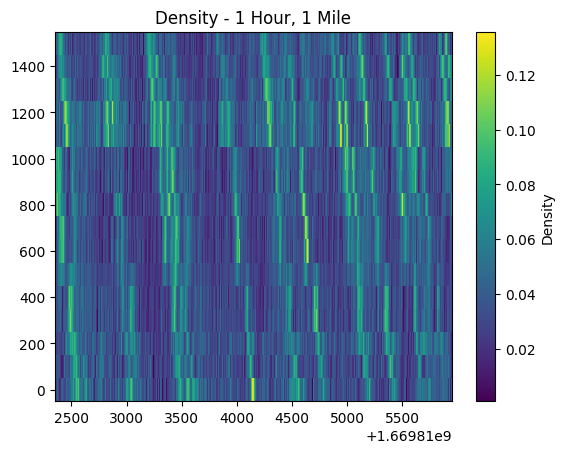

In [44]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16)).T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16)).T
density_result_display = np.array(i24macro_lane_data[-1]["density"].reshape((3600, 16)).T, dtype=np.float64)
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

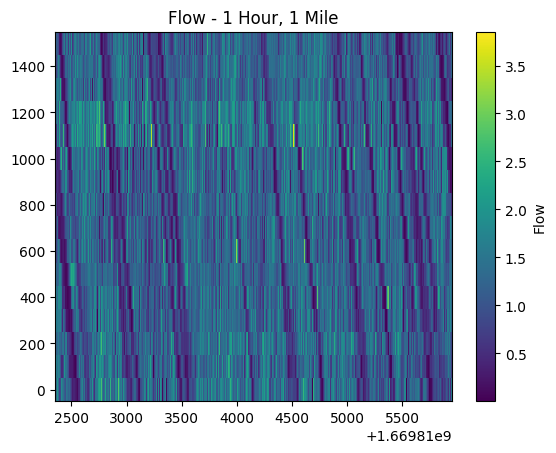

In [45]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16)).T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16)).T
flow_result_display = np.array(i24macro_lane_data[-1]["flow"].reshape((3600, 16)).T, dtype=np.float64)
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [46]:
def sim_real_data(lane_data, lane_flow, dx = 100.0, dt = 1.0, v_f=35.0, rho_j=0.10):
    lane_data = lane_data.reshape((3600, 16))
    lane_flow = lane_flow.reshape((3600, 16))

    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 1
    dx = dx
    dt = dt

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=v_f,
        w=0.0,
        rho_j=rho_j
    )

    lane_data_source = lane_data[:, 1:-1].reshape((1, 3600, 14))
    lane_flow_source = lane_flow[:, 1:-1].reshape((1, 3600, 14))
    rho_left_measured = lane_data[:, 0].reshape((1, 3600, 1))
    rho_right_measured = lane_data[:, -1].reshape((1, 3600, 1))

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=lane_data_source[:, 0, :], fd=fd, cfg=cfg)

    result_density = np.zeros((3600, 14), dtype=np.float64)
    result_density[0, :] = lane_data_source[0, 0, :]
    result_flow = np.zeros((3600, 14), dtype=np.float64)
    result_flow[0, :] = lane_flow_source[0, 0, :]
    for k in range(3600 - 1):  # 1 hour
        F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
        result_density[k+1, :] = rho
        result_flow[k + 1, :] = F[:, 1:]
        #result[k+1, 0] = rho_left_measured[:, k, 0]
        #result[k+1, -1] = rho_right_measured[:, k, 0]
        #q_cell, v_cell = ctm.derived_flow_and_speed()
    return result_density, result_flow

In [47]:
source_density = np.array(i24macro_lane_data[-1]["density"], dtype=np.float64)
source_flow = np.array(i24macro_lane_data[-1]["flow"], dtype=np.float64)
sim_density, sim_flow = sim_real_data(source_density, source_flow)
sim_flow = sim_flow

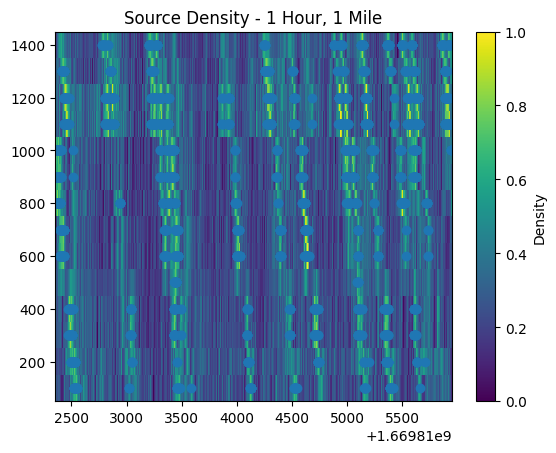

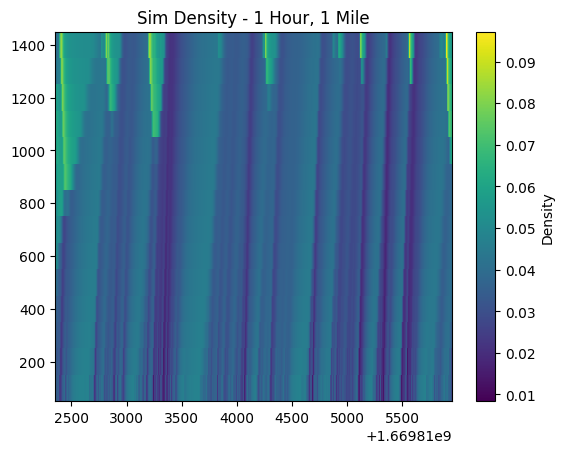

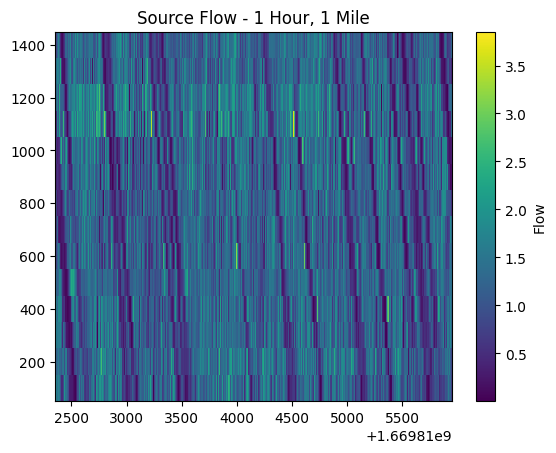

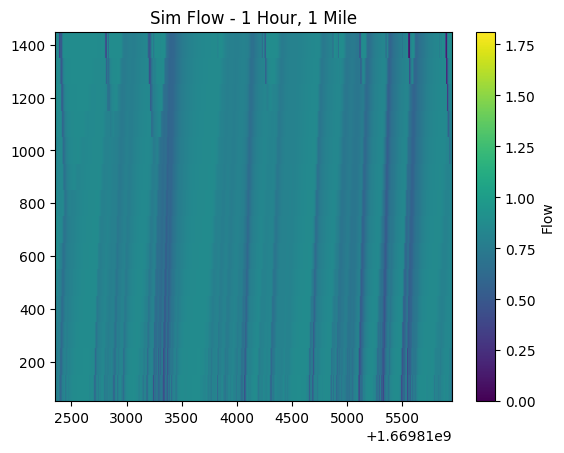

In [48]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16))[:, 1:-1].T
density_result_display = np.array(source_density.reshape((3600, 16))[:, 1:-1].T, dtype=np.float64)
jam_scatters = density_result_display > 0.08
jam_time = timestamp_min_display[jam_scatters]
jam_s = s_min_display[jam_scatters]
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.scatter(jam_time, jam_s)
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
flow_result_display = source_flow.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [49]:
print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())

0.008389558491984597 0.03670541305306979 0.09721691125757186 0.00893022149955763
0.000820946239400655 0.0410276728527232 0.13586990535259247 0.018607483658915024
0.0 0.7839428773379586 1.813521385192871 0.08028681458129559
0.002388676395639777 1.1583459174783193 3.8544631004333496 0.49498893739705374


In [50]:
def objective(trial):
    #v_f=33.0, w=5.0, rho_j=0.20
    v_f = trial.suggest_float('v_f', 10.0, 20.0)
    #w = trial.suggest_float('w', 4.5, 8.0)
    #rho_j = 0.09
    rho_j = trial.suggest_float('rho_j', 0.06, 0.14)
    jam_threshold = trial.suggest_float("jam_threshold", 1.0, 20.0)
    #free_threshold = trial.suggest_float("free_threshold", 15.0, 35.0)
    #jam_threshold = 10.0
    free_threshold = jam_threshold
    combined_flow_in_jam_total = 0.0
    combined_flow_in_free_total = 0.0
    for lane in [-1, -2, -3, -4]:
        source_density = i24macro_lane_data[lane]["density"]
        source_flow = i24macro_lane_data[lane]["flow"]
        sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=v_f, rho_j=rho_j)
        sim_flow = sim_flow
        sim_flow_in_jam = ((sim_flow / sim_density) < jam_threshold).astype(int).reshape(-1)
        source_flow_in_jam = (((source_flow[:, 1:-1] / source_density[:, 1:-1]) < jam_threshold)).astype(int).reshape(-1)
        combined_flow_in_jam_source = -(sim_flow_in_jam * source_flow_in_jam).sum() / (source_flow_in_jam.sum() + 1e-12)
        combined_flow_in_jam_sim = -(sim_flow_in_jam * source_flow_in_jam).sum() / (sim_flow_in_jam.sum() + 1e-12)
        combined_flow_in_jam = combined_flow_in_jam_source# + combined_flow_in_jam_sim

        sim_flow_in_free = ((sim_flow / sim_density) > free_threshold).astype(int).reshape(-1)
        source_flow_in_free = (((source_flow[:, 1:-1] / source_density[:, 1:-1]) > free_threshold)).astype(int).reshape(-1)
        combined_flow_in_free_source = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
        combined_flow_in_free_sim = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
        combined_flow_in_free = combined_flow_in_free_source# + combined_flow_in_free_sim


        print(combined_flow_in_jam, combined_flow_in_free)
        combined_flow_in_jam_total += combined_flow_in_jam
        combined_flow_in_free_total += combined_flow_in_free
    return combined_flow_in_jam_total + combined_flow_in_free_total

study = optuna.create_study()
study.optimize(objective, n_trials=500, n_jobs=1)

study.best_params  # E.g. {'x': 2.002108042}

0.0 -0.995598063147785
-0.03182579564489107 -0.9947794309579744
0.0 -0.999919995199712
0.0 -1.0
-0.0004405286343612333 -1.0
-0.0003992015968063871 -0.9999164839753628
0.0 -1.0
0.0 -1.0
-0.9999999999999998 -0.0002395626892000784
-0.7990633363068687 -0.21164735604146703
-0.19151756129887337 -0.7977502004980794
-0.9926850258175556 -0.004056077876695233
-0.9999999999999998 -0.00024297203391889595
-0.9999999999999998 -0.00027074257303896234
-0.9992966002344664 -0.00028660138524002867
-0.9999999999999999 -0.00027957039349532886
-0.9999999999999998 -0.00024740227610094015
-0.9999999999999998 -0.0002775464890369137
-0.9999999999999998 -0.00029526832509042594
-0.9999999999999998 -0.0002648113820746768
0.0 -0.9997791430751315
0.0 -0.9994962825653322
0.0 -1.0
0.0 -1.0
-0.9999999999999999 -0.0002536075676498187
-0.9999999999999999 -0.00028622726444797167
-0.9999999999999999 -0.00025738038246724833
-0.9999999999999998 -0.00027653476796219014
-0.001592356687898088 -0.9994912909002116
-0.011685116851

{'v_f': 10.050847695496072,
 'rho_j': 0.06602478549553897,
 'jam_threshold': 3.0884807639026195}

In [51]:
study.best_params

{'v_f': 10.050847695496072,
 'rho_j': 0.06602478549553897,
 'jam_threshold': 3.0884807639026195}

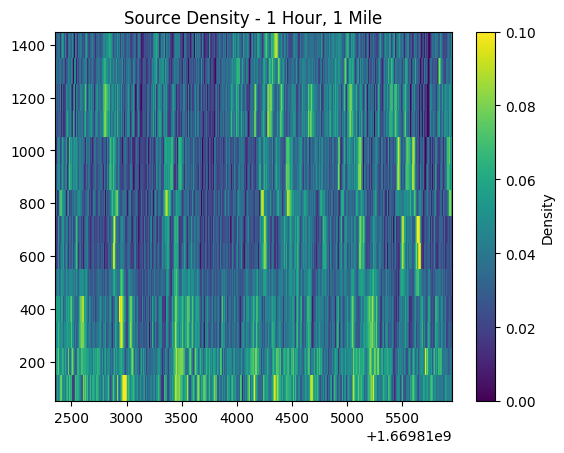

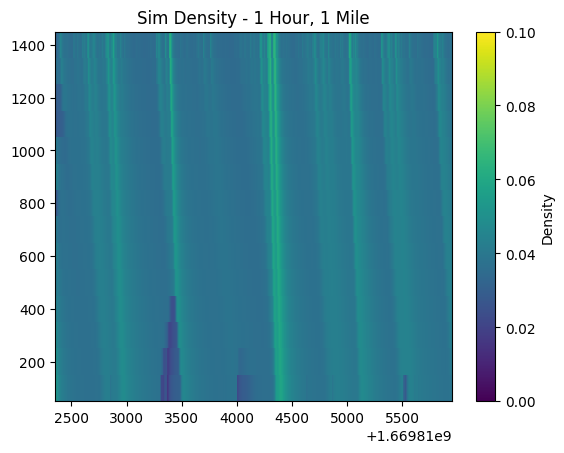

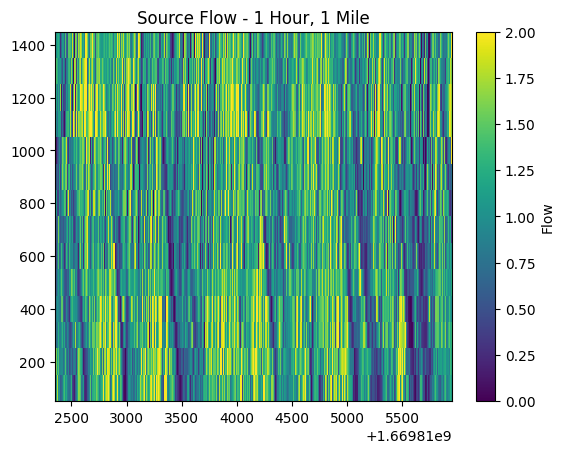

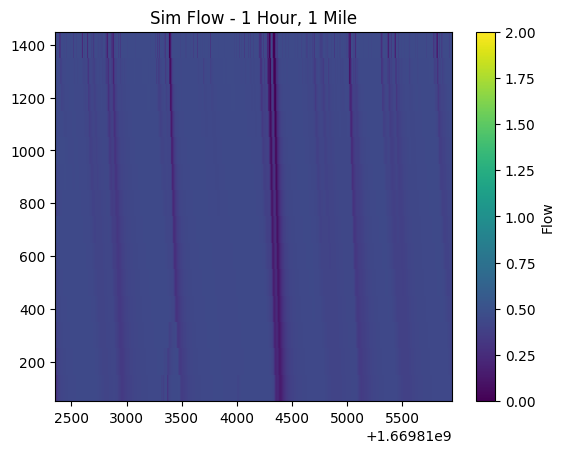

0.012420857233036592 0.04004872552495832 0.06468630452236047 0.004782758063414819
0.000117144766 0.03995652 0.109216034 0.01674538
0.0 0.41267872503161507 1.5748792886734009 0.052829751832921976
4.2302898e-05 1.1113763 3.9869676 0.48642206
0.0 10.546636110692589 34.8362538457286 2.0841428027098554
0.21884987 30.597824 45.000027 12.349941


In [52]:
source_density = i24macro_lane_data[-4]["density"]
source_flow = i24macro_lane_data[-4]["flow"]
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=27.648789930415624, rho_j=0.06475131423016785)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
density_result_display = source_density.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
flow_result_display = source_flow.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())

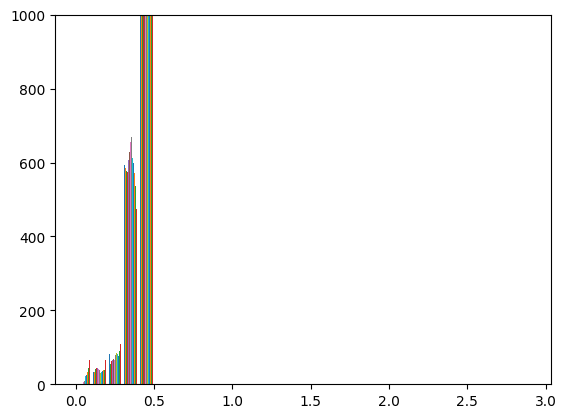

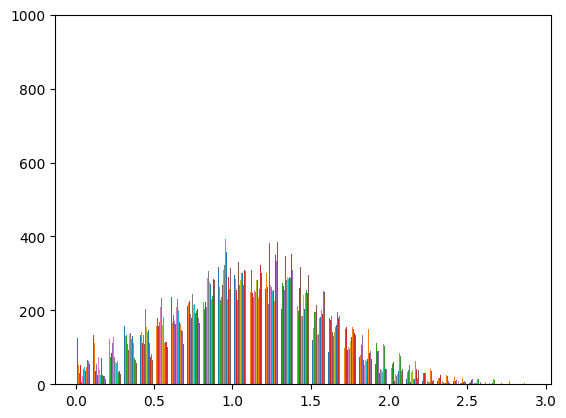

In [53]:
plt.hist(sim_flow, bins=np.arange(0, 3.0, 0.1))
plt.ylim(0, 1000)
plt.show()
plt.hist(source_flow, bins=np.arange(0, 3.0, 0.1))
plt.ylim(0, 1000)
plt.show()

# Simulate multiple lanes simultaneously!

In [54]:
def sim_real_data_multilane(lane_data, lane_flow, dx = 100.0, dt = 1.0, v_f=35.0, rho_j=0.10, lambda_lc=0.005):
    time_size = 3600
    longitudinal_range = 16
    lane_data = lane_data.reshape((-1, time_size, 16))
    lane_flow = lane_flow.reshape((-1, time_size, 16))

    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 4
    dx = dx
    dt = dt

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=v_f,
        w=0.0,
        rho_j=rho_j
    )

    lane_data_source = lane_data[:, :, :1:-1].reshape((lanes, time_size, longitudinal_range - 2))
    lane_flow_source = lane_flow[:, :, 1:-1].reshape((lanes, time_size, longitudinal_range - 2))
    rho_left_measured = lane_data[:, :, 0].reshape((lanes, time_size, 1))
    rho_right_measured = lane_data[:, :, -1].reshape((lanes, time_size, 1))

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes, lambda_lc=lambda_lc)
    ctm = CTMSolver(rho_init=lane_data_source[:, 0, :], fd=fd, cfg=cfg)

    result_density = np.zeros((lanes, time_size, longitudinal_range - 2), dtype=np.float64)
    result_density[:, :, 0] = lane_data_source[:, :, 0]
    result_flow = np.zeros((lanes, time_size, longitudinal_range - 2), dtype=np.float64)
    result_flow[:, :, 0] = lane_flow_source[:, :, 0]
    for k in range(time_size - 1):  # 1 hour
        F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
        result_density[:, k+1, :] = rho
        result_flow[:, k + 1, :] = F[:, 1:]
        #result[k+1, 0] = rho_left_measured[:, k, 0]
        #result[k+1, -1] = rho_right_measured[:, k, 0]
        #q_cell, v_cell = ctm.derived_flow_and_speed()
    return result_density, result_flow

In [55]:
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, 3600, 16) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, 3600, 16) for i in [-1, -2, -3, -4]], axis=0)
print(source_density.shape, source_flow.shape)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow)
sim_flow = sim_flow

(4, 3600, 16) (4, 3600, 16)


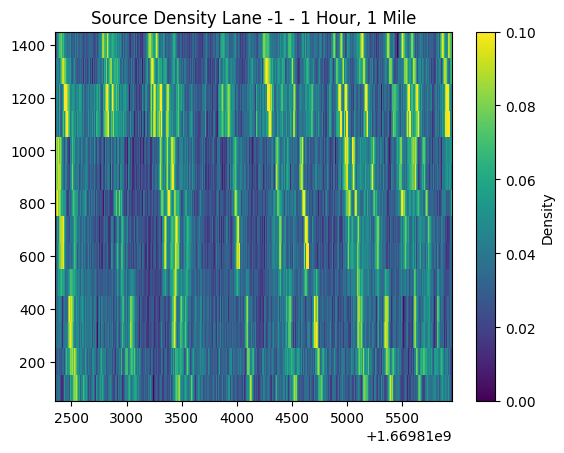

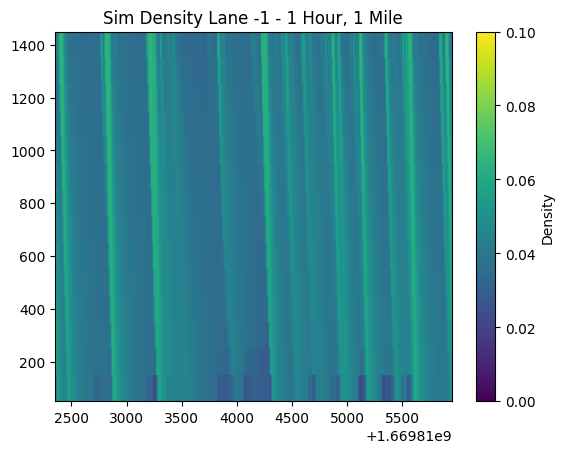

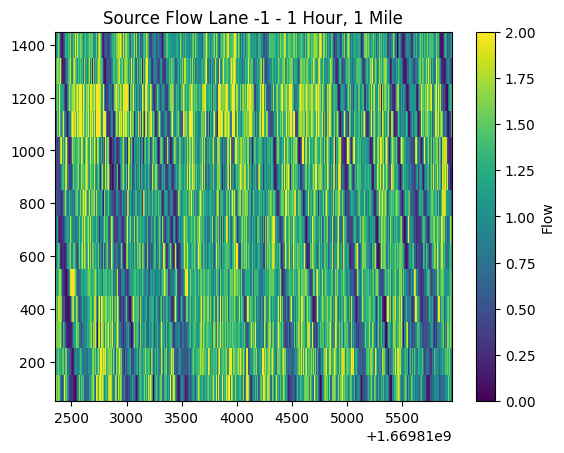

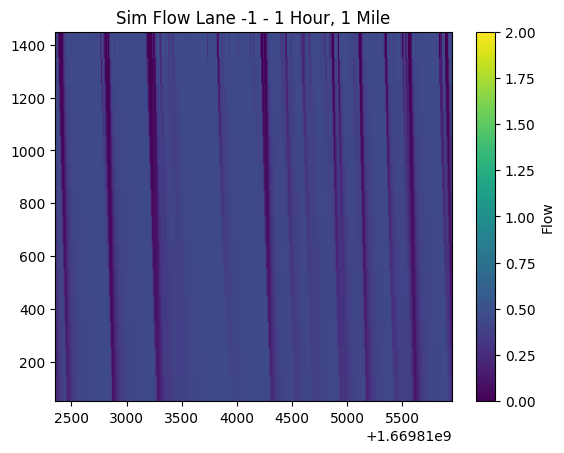

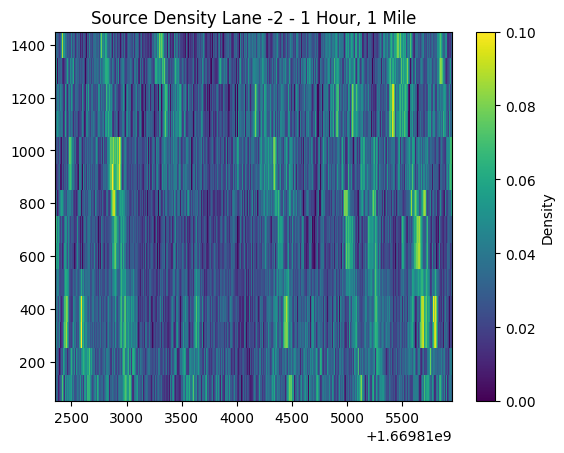

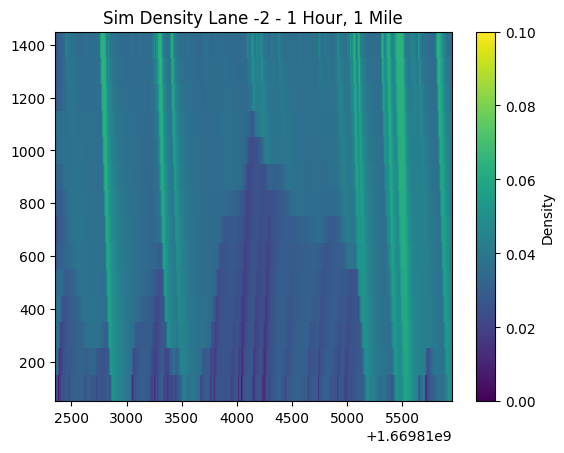

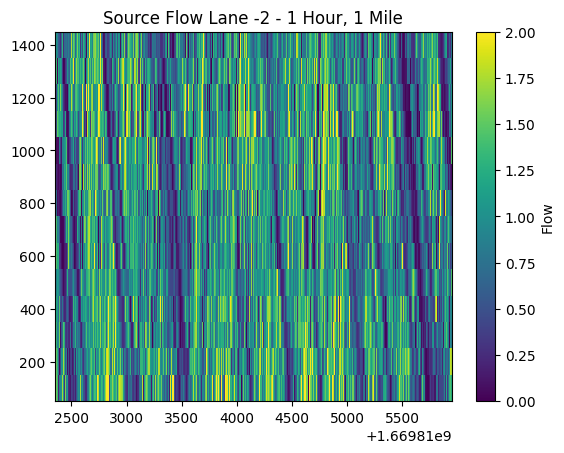

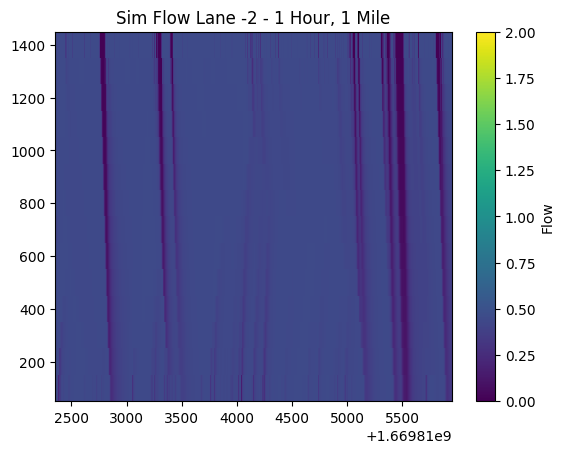

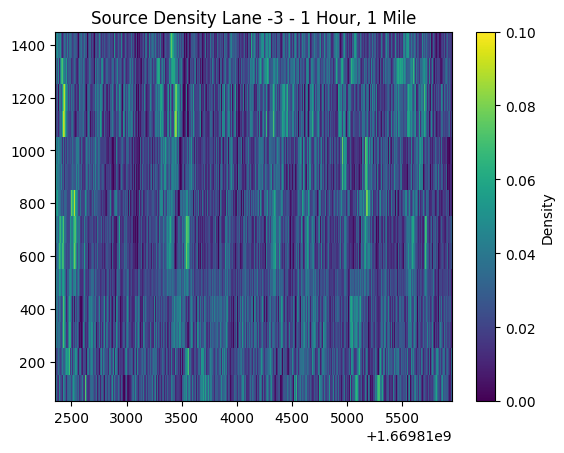

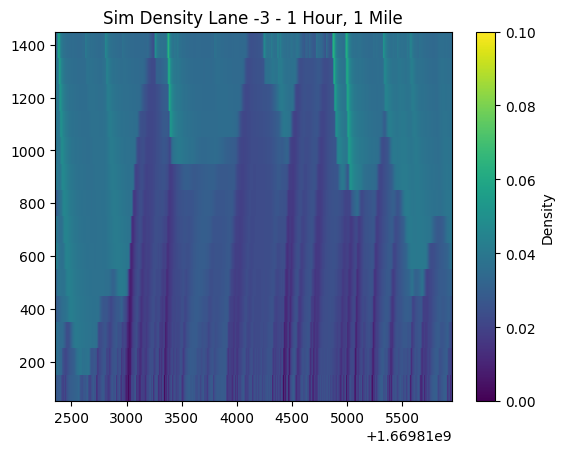

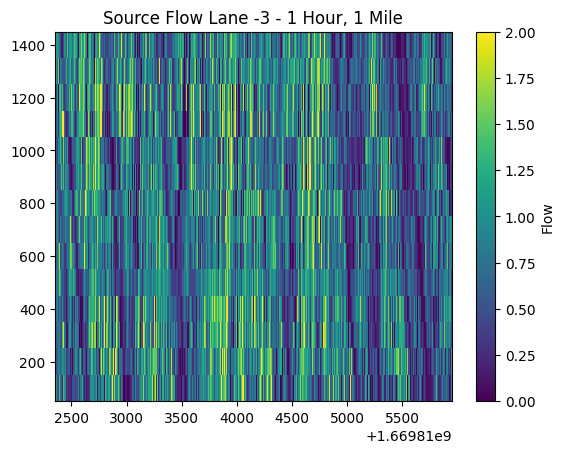

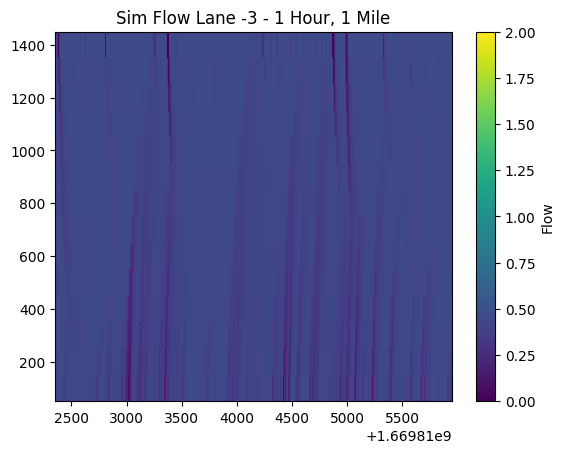

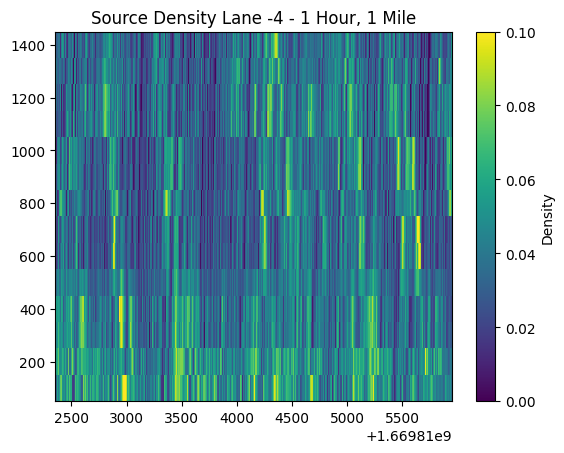

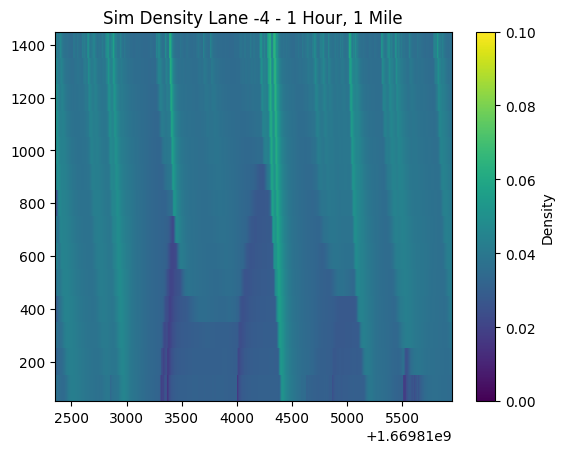

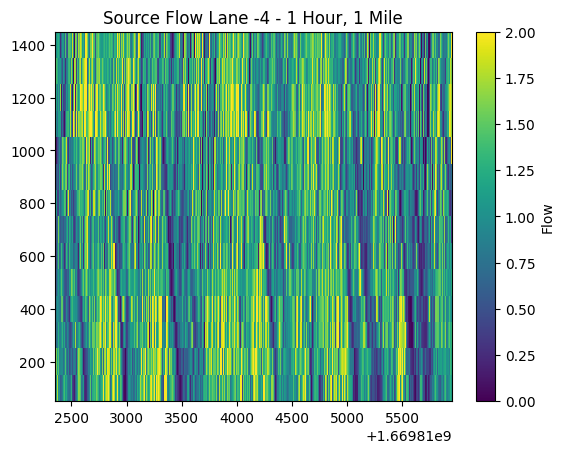

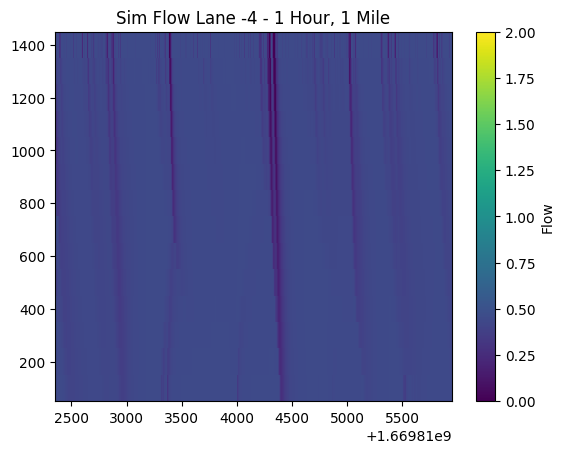

0.0 0.03666590281173584 0.06643961411340742 0.009323611181628782
2.324046e-06 0.034910873 0.1358699 0.017199803
0.0 0.40086883147042285 1.390933871269226 0.0746491612862023
1.4213207e-07 0.99398106 3.9869676 0.505271
0.0 11.942252897779484 41.216083872174245 4.02791407851938
0.029910343 31.333975 45.000027 13.40267


In [56]:
lanes = 4
time_length = 3600
road_length = 16
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=27.648789930415624, rho_j=0.06475131423016785, lambda_lc=0.005)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T

for i, lane in enumerate([-1, -2, -3, -4]):
    density_result_display = source_density.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Source Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    density_result_display = sim_density.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Sim Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    flow_result_display = source_flow.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Source Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    flow_result_display = sim_flow.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Sim Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())

In [ ]:
i = 0
def objective(trial):
    global i
    density_max = 0.15
    velocity_max = 45.0
    flow_max = velocity_max * density_max
    optuna.logging.set_verbosity(optuna.logging.INFO)
    #v_f=33.0, w=5.0, rho_j=0.20
    v_f = trial.suggest_float('v_f', 10.0, 90.0)
    #w = trial.suggest_float('w', 4.5, 8.0)
    #rho_j = 0.09
    rho_j = trial.suggest_float('rho_j', 0.05, 0.15)
    #jam_threshold = trial.suggest_float("jam_threshold", 0.1, 15.0)
    #jam_threshold = 15.0
    #lambda_lc = -0.5
    lambda_lc = trial.suggest_float("lambda_lc", 0.01, 1.0)
    #dy = trial.suggest_float("dy", 2.5, 5.0)
    #free_threshold = trial.suggest_float("free_threshold", 15.0, 35.0)
    jam_threshold = 5.0
    free_threshold = jam_threshold
    combined_flow_in_jam = 0.0
    combined_flow_in_free = 0.0
    source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0).astype(np.float64)
    source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0).astype(np.float64)
    sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=v_f, rho_j=rho_j, lambda_lc=lambda_lc)
    sim_flow_in_jam = ((sim_flow / (sim_density + 1e-12)) < jam_threshold).astype(int).reshape(-1)
    source_flow_in_jam = (((source_flow[:, :, 1:-1] / source_density[:, :, 1:-1]) < jam_threshold)).astype(int).reshape(-1)
    sim_flow_in_free = ((sim_flow / (sim_density + 1e-12)) > free_threshold).astype(int).reshape(-1)
    source_flow_in_free = (((source_flow[:, :, 1:-1] / source_density[:, :, 1:-1]) > free_threshold)).astype(int).reshape(-1)
    combined_flow_in_jam = -(sim_flow_in_jam * source_flow_in_jam).sum() / (source_flow_in_jam.sum() + 1e-12)
    combined_flow_in_free = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
    sim_flow_mean, sim_flow_std = sim_flow.mean(), sim_flow.std()
    source_flow_mean, source_flow_std = source_flow.mean(), source_flow.std()
    flow_mean_diff = abs(sim_flow_mean - source_flow_mean) / flow_max
    flow_std_diff = abs(sim_flow_std - source_flow_std)

    sim_density_mean, sim_density_std = sim_density.mean(), sim_density.std()
    source_density_mean, source_density_std = source_density.mean(), source_density.std()
    density_mean_diff = abs(sim_density_mean - source_density_mean) / density_max
    density_std_diff = abs(sim_flow_std - source_flow_std)

    sim_velocity = sim_flow / np.maximum(sim_density, 1e-12)
    source_velocity = source_flow / np.maximum(source_density, 1e-12)
    sim_velocity_mean = sim_velocity.mean()
    source_velocity_mean = source_velocity.mean()
    velocity_mean_diff = abs(sim_velocity_mean - source_velocity_mean) / velocity_max
    #if ((i % 25) == 0):
        #print(combined_flow_in_jam + combined_flow_in_free, combined_flow_in_jam, combined_flow_in_free, flow_mean_diff, flow_std_diff)
    #print(flow_mean_diff, density_mean_diff, velocity_mean_diff)
    #i = i + 1
    #return combined_flow_in_jam + combined_flow_in_free
    #return flow_mean_diff + flow_std_diff
    print(flow_mean_diff, density_mean_diff, velocity_mean_diff, combined_flow_in_jam)
    return flow_mean_diff + density_mean_diff + velocity_mean_diff + combined_flow_in_jam

study = optuna.create_study()
study.optimize(objective, n_trials=500, n_jobs=1)

study.best_params  # E.g. {'x': 2.002108042}

[I 2026-03-31 17:00:42,252] A new study created in memory with name: no-name-1cc59041-73ab-4d60-a2e9-b93e9c890fb5
[I 2026-03-31 17:00:42,489] Trial 0 finished with value: 0.39086834051878866 and parameters: {'v_f': 84.20226485797005, 'rho_j': 0.07330907746870988, 'jam_threshold': 0.4789697718130377, 'lambda_lc': 0.7017313602377444}. Best is trial 0 with value: 0.39086834051878866.


0.06188539656633201 0.010018786191043396 0.31896415776141324 0.0


[I 2026-03-31 17:00:42,708] Trial 1 finished with value: 0.042895117727062476 and parameters: {'v_f': 44.514033902041135, 'rho_j': 0.12464312222443623, 'jam_threshold': 2.1490126189559096, 'lambda_lc': 0.7760469196544648}. Best is trial 1 with value: 0.042895117727062476.


0.014300152292497703 0.005932057412842788 0.02266290802172198 0.0


[I 2026-03-31 17:00:42,912] Trial 2 finished with value: -0.38870142478213254 and parameters: {'v_f': 16.924344865989056, 'rho_j': 0.07324993709989443, 'jam_threshold': 13.351572993793583, 'lambda_lc': 0.18662939429843967}. Best is trial 2 with value: -0.38870142478213254.


...

[I 2026-03-31 17:02:25,015] Trial 498 finished with value: -0.42339175631544385 and parameters: {'v_f': 18.414947529492665, 'rho_j': 0.1361291932773842, 'jam_threshold': 14.717633805908262, 'lambda_lc': 0.6298947442207016}. Best is trial 262 with value: -0.5134432686138561.


0.07714261710030774 0.0010941790628629655 0.3916383955562048 -0.8932669480348193


[I 2026-03-31 17:02:25,222] Trial 499 finished with value: -0.480373097661306 and parameters: {'v_f': 16.18995819111618, 'rho_j': 0.1329601444416169, 'jam_threshold': 14.420812880012939, 'lambda_lc': 0.25970126953743156}. Best is trial 262 with value: -0.5134432686138561.


0.08637754278590715 0.0026219113466487607 0.4300186613829906 -0.9993912131768525


{'v_f': 17.49439381276583,
 'rho_j': 0.14771858674825558,
 'jam_threshold': 14.987748542794884,
 'lambda_lc': 0.25422797246487816}

In [114]:
study.best_params

{'v_f': 17.49439381276583,
 'rho_j': 0.14771858674825558,
 'jam_threshold': 14.987748542794884,
 'lambda_lc': 0.25422797246487816}

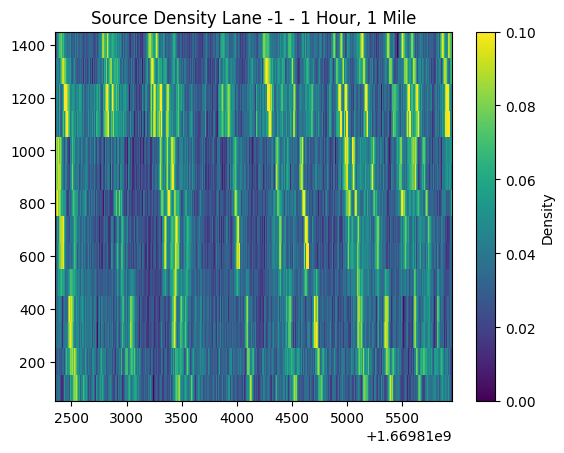

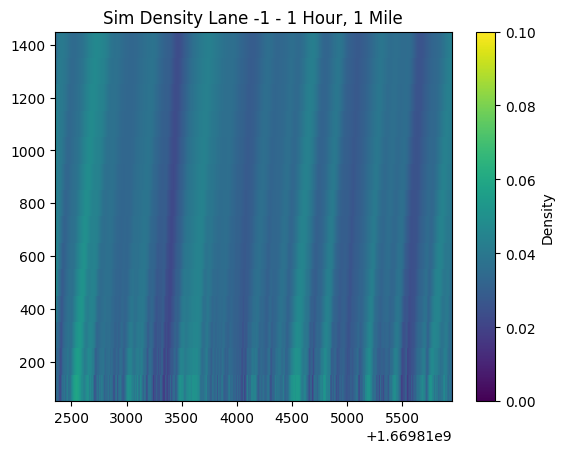

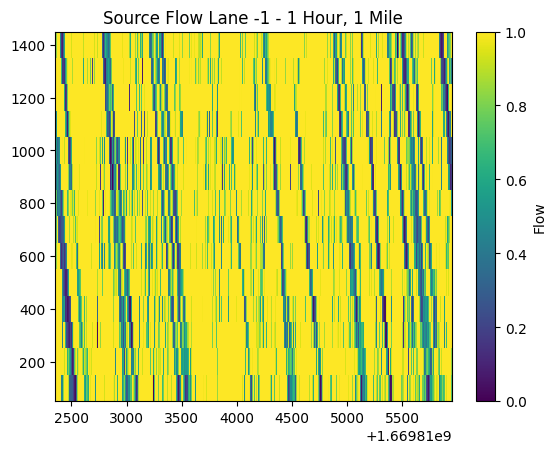

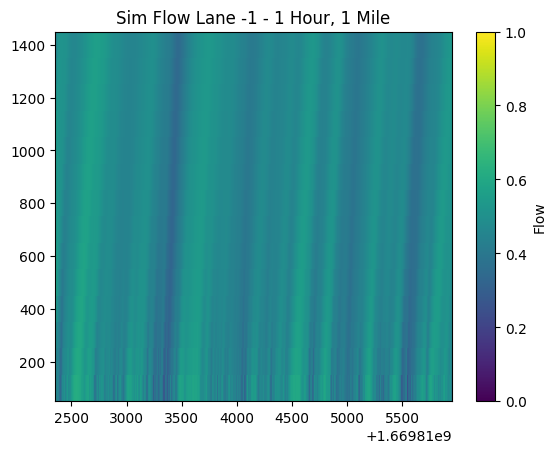

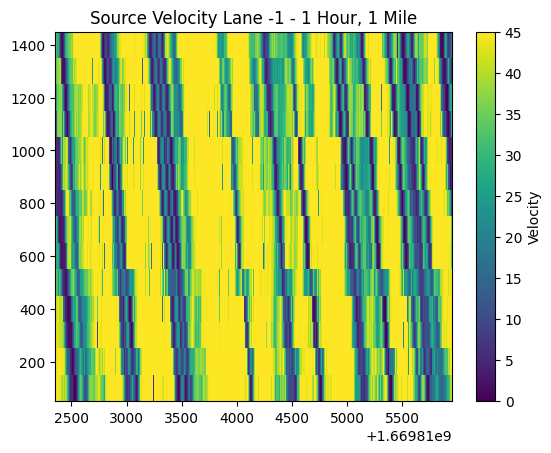

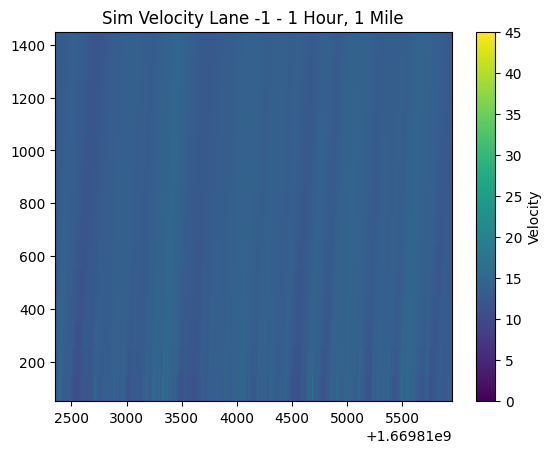

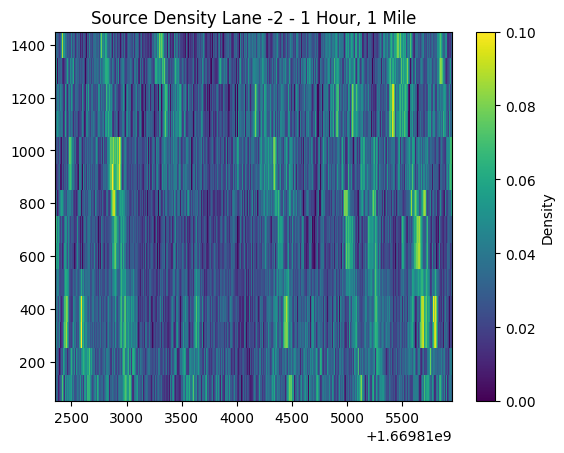

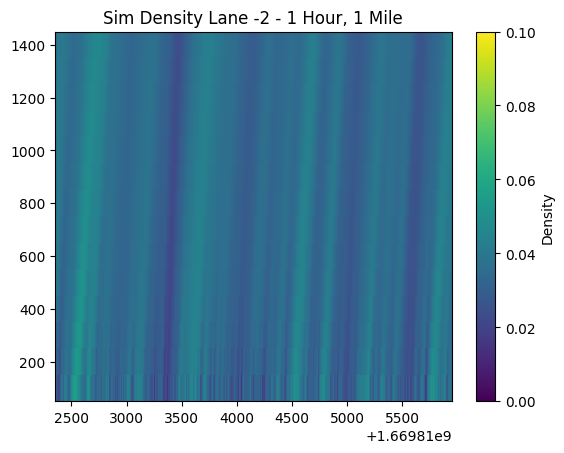

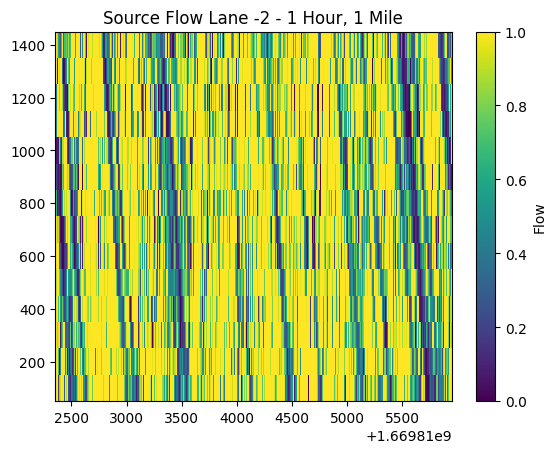

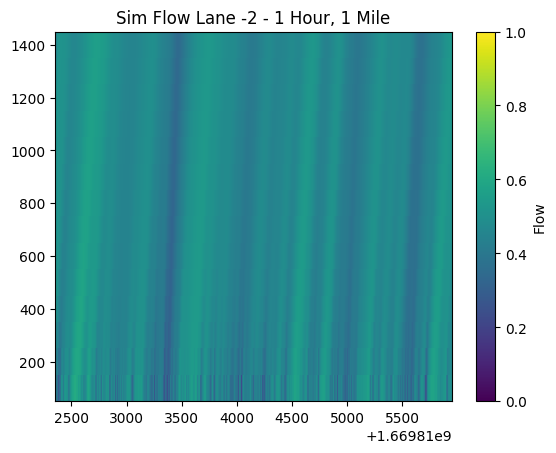

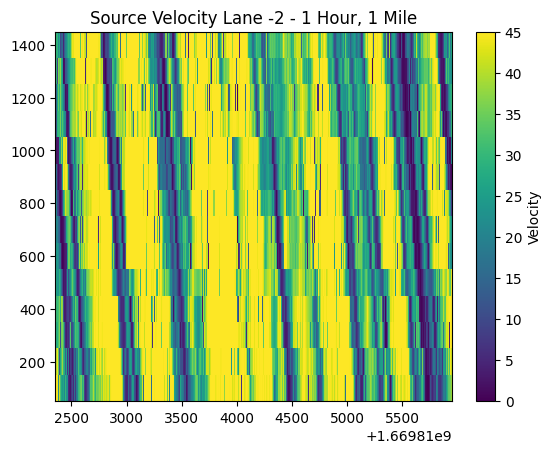

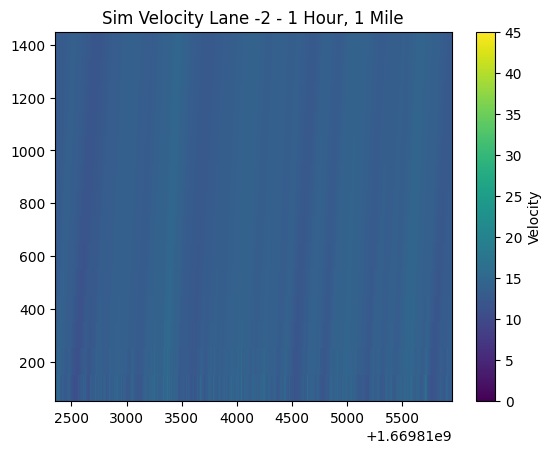

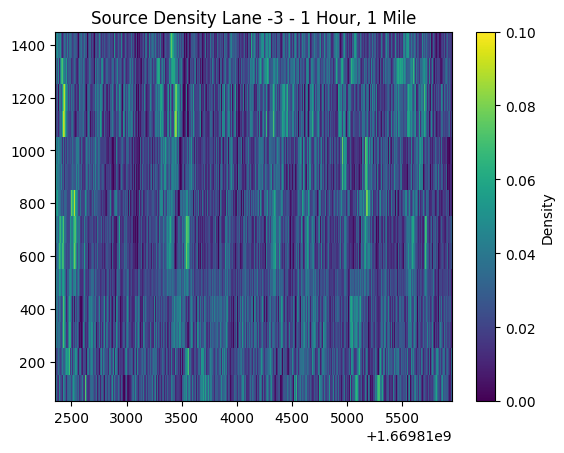

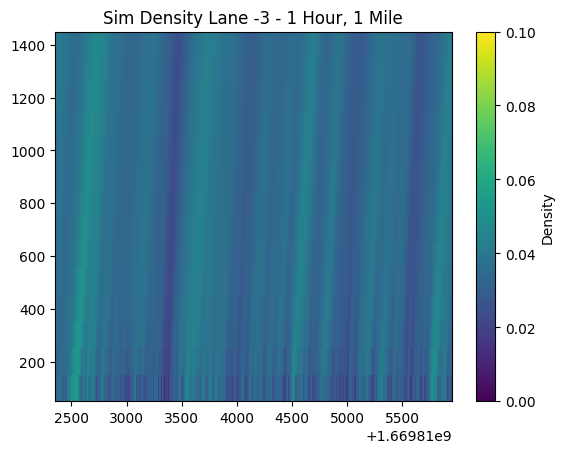

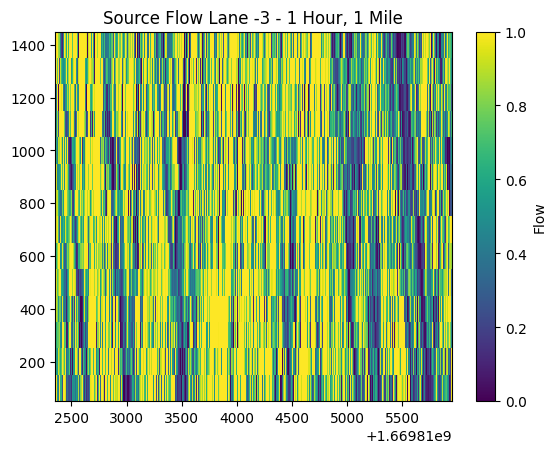

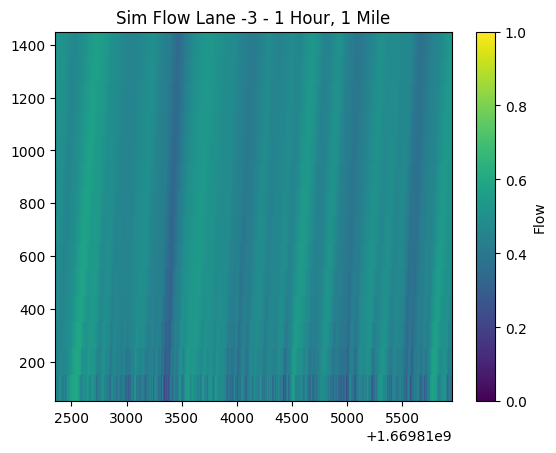

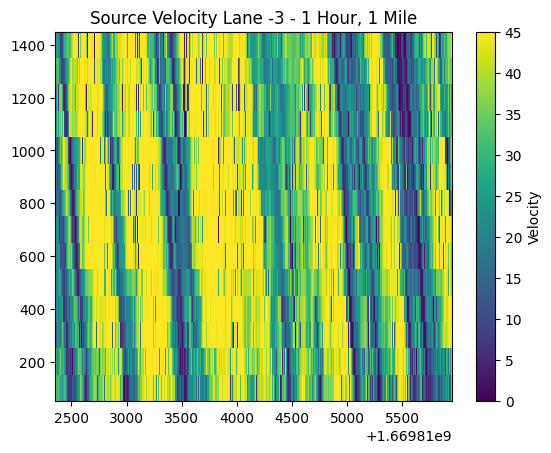

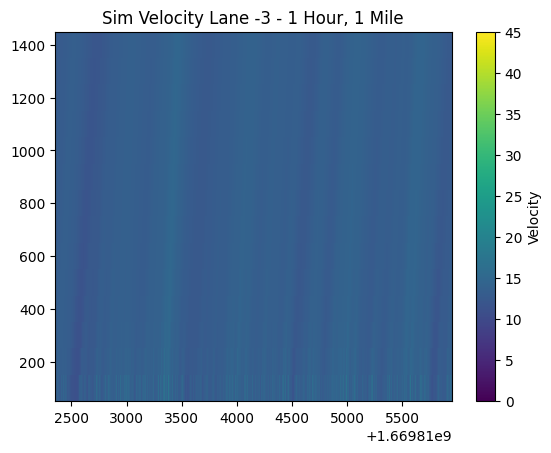

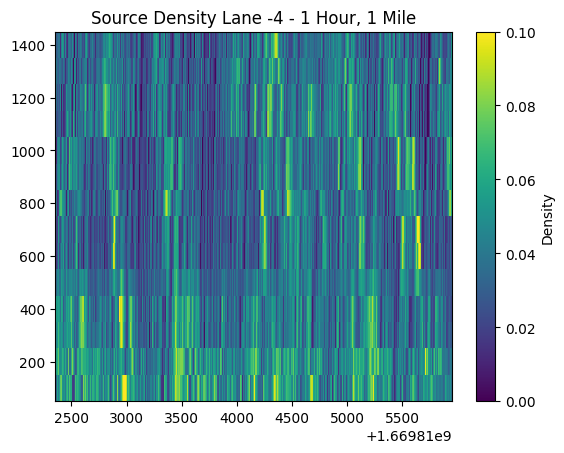

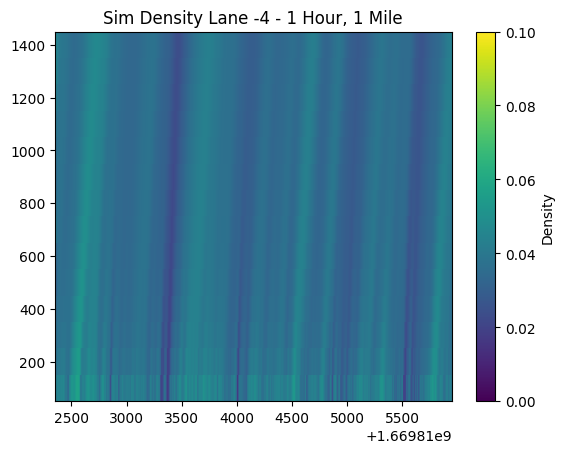

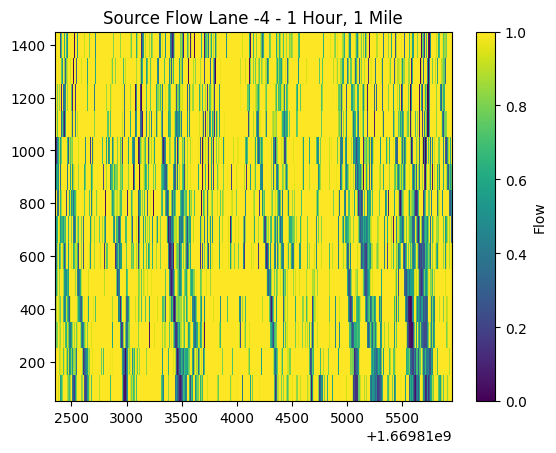

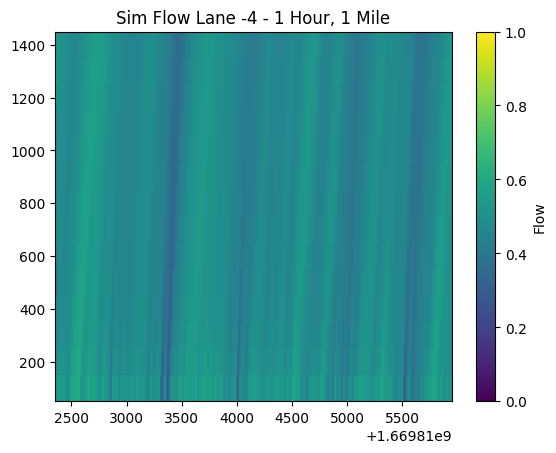

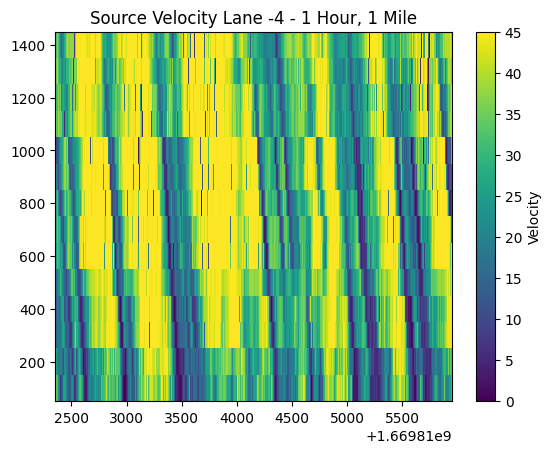

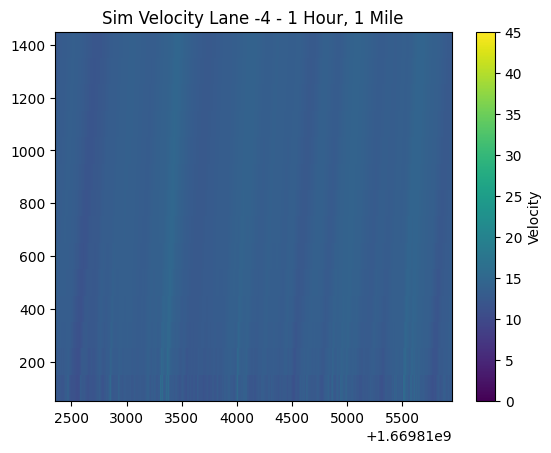

0.0 0.03548661397599881 0.06310528476671502 0.005415185998737557
2.324046e-06 0.034910873 0.1358699 0.017199803
0.0 0.4682151039655213 1.390933871269226 0.04940961974252062
1.4213207e-07 0.99398106 3.9869676 0.505271
0.0 13.287747258598635 41.216083872174245 0.6866911670497121
0.029910343 31.333975 45.000027 13.40267


In [115]:
# Road 1 Config
#{'v_f': 19.55523695153419,
# 'rho_j': 0.12418479516687536,
# 'lambda_lc': 0.0001714009312035207}

# Road 2 Config
# v_f=26.91476041653862, rho_j=0.06539548928555416, lambda_lc=0.19539554271314807)
lanes = 4
time_length = 3600
road_length = 16
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=17.49439381276583, rho_j=0.14771858674825558, lambda_lc=0.25422797246487816)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T

for i, lane in enumerate([-1, -2, -3, -4]):
    density_result_display = source_density.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Source Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    density_result_display = sim_density.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Sim Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    flow_result_display = source_flow.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
    plt.title(f'Source Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    flow_result_display = sim_flow.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=1.0)
    plt.title(f'Sim Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    velocity_result_display = source_velocity.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=45.0)
    plt.title(f'Source Velocity Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Velocity')
    plt.show()

    velocity_result_display = sim_velocity.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=45.0)
    plt.title(f'Sim Velocity Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Velocity')
    plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())